In [5]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

load_dotenv()

True

In [6]:
spark = (
    SparkSession.builder
    .appName("uk-property-flip-detector")
    .config("spark.jars", "jars/postgresql-jdbc.jar")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)

BASE_YEAR = 1995
MAX_PERIOD = 377
MIN_INTERVAL = 24 

In [7]:
bench = pd.read_csv("data/processed/bmn_index_case_shiller_min24m_nn.csv",
                    index_col="month", parse_dates=True).iloc[:, 0]

log_idx = pd.DataFrame({
    "period": np.arange(len(bench)),
    "log_idx": np.log(bench.values / 100),
})
log_idx_sdf = spark.createDataFrame(log_idx)
print(len(log_idx), log_idx.head(3))

378    period   log_idx
0       0  0.000000
1       1  0.010318
2       2  0.012019


In [ ]:
df = (
    spark.read.format("jdbc")
    .option("url", f"jdbc:postgresql://{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}")
    .option("dbtable", "repeat_sale_pairs_regression")
    .option("user", os.environ["PGUSER"])
    .option("password", os.environ["PGPASSWORD"])
    .option("driver", "org.postgresql.Driver")
    .option("partitionColumn", "property_id")
    .option("lowerBound", "1")
    .option("upperBound", "15184630")
    .option("numPartitions", "8")
    .load()
)
df.printSchema()

root
 |-- property_id: long (nullable = true)
 |-- prev_transaction_id: string (nullable = true)
 |-- curr_transaction_id: string (nullable = true)
 |-- prev_date_of_transfer: date (nullable = true)
 |-- curr_date_of_transfer: date (nullable = true)
 |-- prev_price: integer (nullable = true)
 |-- curr_price: integer (nullable = true)
 |-- prev_ppd_category: string (nullable = true)
 |-- curr_ppd_category: string (nullable = true)
 |-- prev_duration: string (nullable = true)
 |-- curr_duration: string (nullable = true)
 |-- holding_period_days: integer (nullable = true)
 |-- log_price_ratio: decimal(38,18) (nullable = true)
 |-- prev_old_new: string (nullable = true)
 |-- curr_old_new: string (nullable = true)
 |-- property_type: string (nullable = true)



In [9]:
period = lambda c: (F.year(c) - BASE_YEAR) * 12 + (F.month(c) - 1)

pairs = (
    df
    .filter((F.col("prev_old_new") == "N") & (F.col("curr_old_new") == "N"))
    .withColumn("prev_period", period("prev_date_of_transfer"))
    .withColumn("curr_period", period("curr_date_of_transfer"))
    .filter(F.col("curr_period") <= MAX_PERIOD)
    .withColumn("interval", F.col("curr_period") - F.col("prev_period"))
    .withColumn("log_price_ratio", F.col("log_price_ratio").cast("double"))
)

li = F.broadcast(log_idx_sdf)
scored = (
    pairs
    .join(li.withColumnRenamed("period", "prev_period")
            .withColumnRenamed("log_idx", "prev_log_idx"), "prev_period")
    .join(li.withColumnRenamed("period", "curr_period")
            .withColumnRenamed("log_idx", "curr_log_idx"), "curr_period")
    .withColumn("market_return", F.col("curr_log_idx") - F.col("prev_log_idx"))
    .withColumn("excess", F.col("log_price_ratio") - F.col("market_return"))
    .cache()
)
print(scored.count())

11049915


In [10]:
(
    scored
    .withColumn("hold_bucket",
        F.when(F.col("interval") < 6, "0-5m")
         .when(F.col("interval") < 12, "6-11m")
         .when(F.col("interval") < 24, "12-23m")
         .otherwise("24m+"))
    .groupBy("hold_bucket")
    .agg(
        F.count("*").alias("n"),
        F.mean("excess").alias("mean"),
        F.percentile_approx("excess", [0.5, 0.75, 0.9, 0.95, 0.99]).alias("p50_75_90_95_99"),
    )
    .orderBy("hold_bucket")
    .show(truncate=False)
)

+-----------+-------+--------------------+-------------------------------------------------------------------------------------------------------+
|hold_bucket|n      |mean                |p50_75_90_95_99                                                                                        |
+-----------+-------+--------------------+-------------------------------------------------------------------------------------------------------+
|0-5m       |205472 |0.17864288501051348 |[0.12100492395464449, 0.31697376307203423, 0.5308243431619286, 0.6859119313566324, 1.0806694386608404] |
|12-23m     |954829 |0.09016036889194823 |[0.04546318176958125, 0.16817691343656604, 0.3578182817312103, 0.5155723612879414, 0.9499224670352566] |
|24m+       |9528550|0.013392624162206988|[0.001433603151083096, 0.13175515665867182, 0.2904774231330963, 0.4232739966529404, 0.8268365251998113]|
|6-11m      |361064 |0.16801254056445022 |[0.11187809268590657, 0.2956267815405053, 0.49274766005592263, 0.64726081348

In [11]:
FLIP_MAX_INTERVAL = 12      # months
CONTROL_PCTL = 0.95
MIN_EXCESS_GBP = 10_000

threshold = (
    scored.filter(F.col("interval") >= MIN_INTERVAL)
    .agg(F.percentile_approx("excess", CONTROL_PCTL).alias("t"))
    .first()["t"]
)
print(f"excess threshold: {threshold:.3f} log pts ({np.exp(threshold) - 1:.0%} above market)")

flagged = (
    scored
    .withColumn("expected_price", F.col("prev_price") * F.exp("market_return"))
    .withColumn("excess_gbp", F.col("curr_price") - F.col("expected_price"))
    .withColumn("is_flip",
        (F.col("interval") < FLIP_MAX_INTERVAL)
        & (F.col("excess") > threshold)
        & (F.col("excess_gbp") >= MIN_EXCESS_GBP))
    .withColumn("sale_year", F.year("curr_date_of_transfer"))
)

flagged.groupBy("is_flip").count().show()

excess threshold: 0.423 log pts (53% above market)
+-------+--------+
|is_flip|   count|
+-------+--------+
|   true|   80931|
|  false|10968984|
+-------+--------+



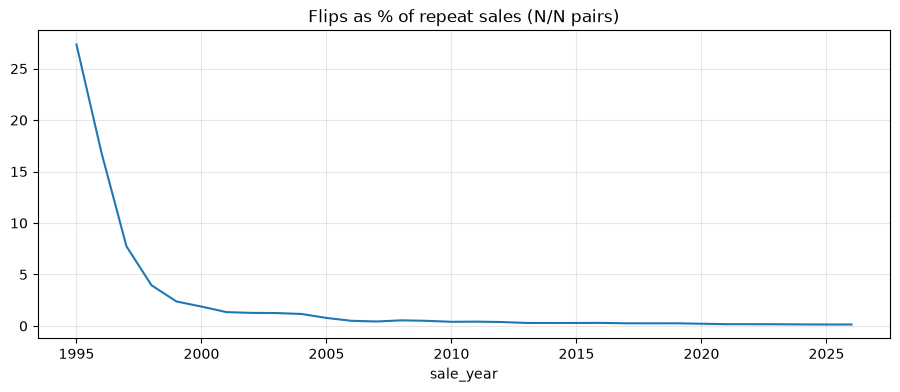

           resales  flips  median_flip_gain  flip_rate_pct
sale_year                                                 
1995         11293   3088      20083.376866      27.344373
1996         38096   6413      21184.000472      16.833788
1997         84114   6507      24026.177185       7.735930
1998        136649   5406      24268.188073       3.956121
1999        220382   5238      28589.099018       2.376782
2000        265111   4993      29700.440727       1.883362
2001        355934   4788      29685.197130       1.345193
2002        446290   5666      32639.334274       1.269578
2003        454123   5692      31897.579596       1.253405
2004        488331   5690      36118.091239       1.165193
2005        441183   3431      44268.660868       0.777682
2006        572722   2862      55813.750998       0.499719
2007        554010   2407      68151.844689       0.434469
2008        262773   1433      65660.722845       0.545338
2009        259388   1295      58349.610059       0.4992

In [12]:
by_year = (
    flagged
    .groupBy("sale_year")
    .agg(
        F.count("*").alias("resales"),
        F.sum(F.col("is_flip").cast("int")).alias("flips"),
        F.expr("percentile_approx(CASE WHEN is_flip THEN excess_gbp END, 0.5)").alias("median_flip_gain"),
    )
    .withColumn("flip_rate_pct", 100 * F.col("flips") / F.col("resales"))
    .orderBy("sale_year")
    .toPandas()
    .set_index("sale_year")
)

fig, ax = plt.subplots(figsize=(11, 4))
by_year["flip_rate_pct"].plot(ax=ax)
ax.set_title("Flips as % of repeat sales (N/N pairs)")
ax.grid(alpha=0.3)
plt.show()
print(by_year)

In [13]:
(
    flagged.filter("is_flip")
    .select("property_id", "property_type", "prev_date_of_transfer", "prev_price",
            "curr_date_of_transfer", "curr_price", "interval",
            F.round("excess", 3).alias("excess"), F.round("excess_gbp").alias("excess_gbp"))
    .orderBy(F.rand(seed=42))
    .show(20, truncate=False)
)

+-----------+-------------+---------------------+----------+---------------------+----------+--------+------+----------+
|property_id|property_type|prev_date_of_transfer|prev_price|curr_date_of_transfer|curr_price|interval|excess|excess_gbp|
+-----------+-------------+---------------------+----------+---------------------+----------+--------+------+----------+
|3802080    |T            |2004-10-08           |35000     |2005-05-27           |62950     |7       |0.574 |27483.0   |
|6004725    |T            |1996-05-31           |23000     |1996-10-25           |38500     |5       |0.491 |14943.0   |
|4369477    |F            |1996-02-16           |25000     |1996-11-01           |51500     |9       |0.674 |25262.0   |
|5598805    |D            |1999-11-10           |65140     |2000-05-31           |275000    |6       |1.362 |204565.0  |
|13978449   |S            |2000-12-22           |310000    |2001-06-28           |522000    |6       |0.454 |190422.0  |
|1802626    |T            |2011-

+----------+--------+
|flip_class|   count|
+----------+--------+
|      NULL|10968984|
|      flip|   73650|
|   extreme|    7281|
+----------+--------+



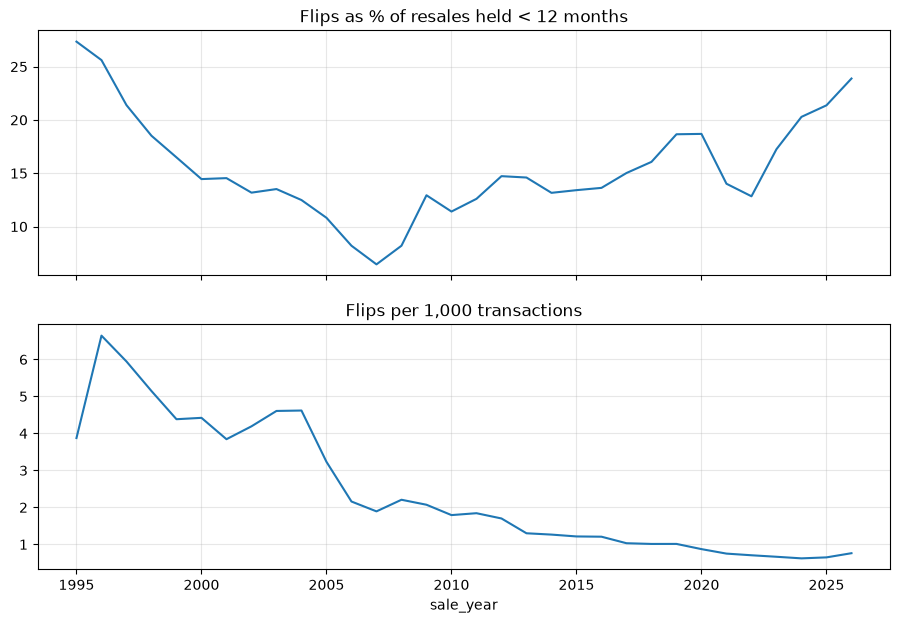

           flips  short_resales  transactions  flip_share_of_short_pct  \
sale_year                                                                
1995        3088          11293        797155                    27.34   
1996        6413          25039        965424                    25.61   
1997        6507          30422       1094661                    21.39   
1998        5406          29196       1050695                    18.52   
1999        5238          31766       1195083                    16.49   
2000        4993          34549       1129579                    14.45   
2001        4788          32926       1246046                    14.54   
2002        5666          42990       1351970                    13.18   
2003        5692          42113       1235651                    13.52   
2004        5690          45570       1232183                    12.49   
2005        3431          31705       1061823                    10.82   
2006        2862          34900       

In [15]:
EXTREME_EXCESS = 1.0

flagged = flagged.withColumn(
    "flip_class",
    F.when(F.col("is_flip") & (F.col("excess") > EXTREME_EXCESS), "extreme")
     .when(F.col("is_flip"), "flip")
)
flagged.groupBy("flip_class").count().show()

short = (
    flagged.filter(F.col("interval") < FLIP_MAX_INTERVAL)
    .groupBy("sale_year")
    .agg(F.count("*").alias("short_resales"))
)

tx = (
    spark.read.format("jdbc")
    .option("url", f"jdbc:postgresql://{os.environ['PGHOST']}:{os.environ['PGPORT']}/{os.environ['PGDATABASE']}")
    .option("query", """
        SELECT EXTRACT(YEAR FROM date_of_transfer)::int AS sale_year, COUNT(*) AS transactions
        FROM staging_price_paid_cleaned
        GROUP BY 1
    """)
    .option("user", os.environ["PGUSER"])
    .option("password", os.environ["PGPASSWORD"])
    .option("driver", "org.postgresql.Driver")
    .load()
    .toPandas()
    .set_index("sale_year")
)

rates = by_year.join(short.toPandas().set_index("sale_year")).join(tx)
rates["flip_share_of_short_pct"] = 100 * rates["flips"] / rates["short_resales"]
rates["flips_per_1000_tx"] = 1000 * rates["flips"] / rates["transactions"]

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
rates["flip_share_of_short_pct"].plot(ax=axes[0])
axes[0].set_title("Flips as % of resales held < 12 months")
rates["flips_per_1000_tx"].plot(ax=axes[1])
axes[1].set_title("Flips per 1,000 transactions")
for ax in axes:
    ax.grid(alpha=0.3)
plt.show()
print(rates[["flips", "short_resales", "transactions",
             "flip_share_of_short_pct", "flips_per_1000_tx"]].round(2))

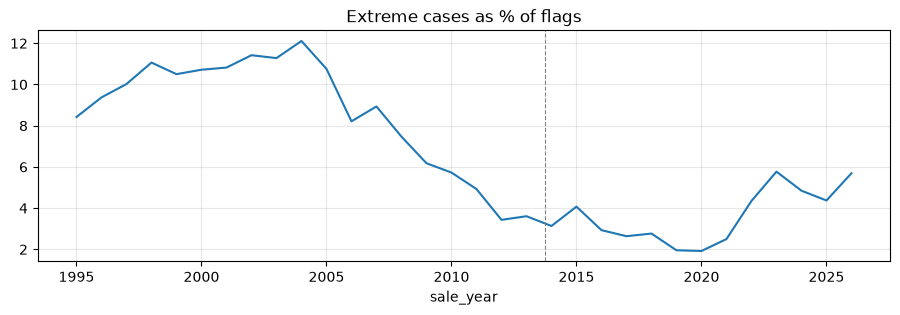

In [16]:
ext = (
    flagged.filter(F.col("flip_class").isNotNull())
    .groupBy("sale_year")
    .agg(F.avg((F.col("flip_class") == "extreme").cast("int")).alias("extreme_share"))
    .orderBy("sale_year")
    .toPandas()
    .set_index("sale_year")
)
ax = (100 * ext["extreme_share"]).plot(figsize=(11, 3), title="Extreme cases as % of flags")
ax.axvline(2013.75, color="grey", linestyle="--", linewidth=0.8)  # Category B recording starts
ax.grid(alpha=0.3)
plt.show()